# $\chi_{UKQ}$-Space Inversion for Detachment-Limited Landscapes

This notebook provides a minimal example workflow for using this repository to invert detachment-limited landscapes in $\chi_{UKQ}$ space.

The code was developed to retrieve spatial patterns of rock uplift rate, $U(x,y)$, from detachment-limited landscapes under the steady-state assumption. The framework can also be used to invert for spatially variable erodibility, $K(x,y)$, and account for spatial variations in precipitation rate, $Q(x,y)$.

For a full description of the method, assumptions, and applications, see:

**Oryan et al. (2025)**  
https://doi.org/10.1029/2024JB030819

## 1. Prepare the DEM

Before running this notebook, download and project the DEM into a metric coordinate system, preferably UTM.

DEM preparation is described in:

```text
examples/prepare_dem.ipynb
```

This preprocessing can be done with GDAL, QGIS, Python, or similar GIS tools.

## 2. Import packages

In [1]:
# Optional and recommended interactive backend for plotting in Jupyter notebooks.:
%matplotlib widget
#
# If the widget backend does not display in VS Code, use:
# %matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# This notebook is assumed to be inside the examples/ directory,
# so we add the repository root directory to the Python path.
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

# Repository-specific imports.
# If one of these imports fails, there is likely a problem with your Python environment
# or with the repository path added above.
import loadAndExportDem as load_dem
import chifrd
import frdplt


/opt/anaconda3/envs/invertchi/lib/python3.11/site-packages/scabbard/config.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.11.15


[I 05/01/26 23:03:54.312 64374486] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


## Load the DEM and define river-extraction parameters

Next, load the prepared DEM. In this example, we use a DEM from the Santa Ynez region.

You also need to define two key parameters for extracting the river network:

- **Base level**: the elevation threshold used to define the downstream reference level.
- **Drainage-area threshold**: the minimum upstream drainage area required for a channel to be treated as a river.

These parameters control which channels are included in the analysis. Some trial and error is usually needed to isolate the detachment-limited part of the river network and avoid including small hillslope channels or poorly resolved tributaries.

For the Santa Ynez example, a base level of `30 m` works fairly well. A drainage-area threshold of `1e6 m²` also tends to work well, corresponding to  `1 km²`.

Loading dem...
getting stack and recs...
Getting rivers...
Retrieved 39877 river nodes in 107 basins


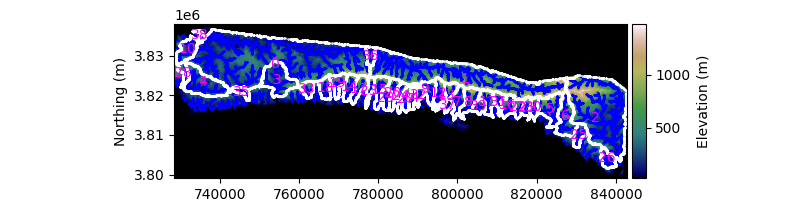

In [2]:
base_level = 30.0          # meters
area_threshold = 1e6       # m², equivalent to 1 km²

dem_path = "DEMs/santa_ynez.tif"

DEM = load_dem.loadDEMDiet(
    dem_path,
    Z0=base_level,
    A0=area_threshold,
)

fig, ax = plt.subplots(figsize=(8, 2))
DEM.PlotAll(ax=ax,numOfBasinsPrint=40)
plt.show()
fig_file = Path("figs") / "sy_retrieved_rivers_and_basins.pdf"
fig_file.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_file, dpi=300)


## Select basins for inversion

Now it is time to choose the rivers for the inversion by selecting the basins you want to include.

You can either use the interactive figure mode to zoom in and out and identify the appropriate basins, or inspect the saved PDF version of the map.

In the basin-selection plot above:

- rivers are shown in blue
- basin outlines are shown in white
- basin numbers are shown in magenta

For the Santa Ynez DEM, rivers north of the ridge are likely not detachment limited, or at least some portions of them may not be. In this example, we are therefore interested primarily in the rivers in the middle of the DEM.

Use the basin numbers to define the set of basins that will be included in the inversion.

In [8]:
from pathlib import Path

# Basin IDs selected from the basin-selection plot.
basinIDs = [18, 19,14,17,23,15,29,20,24,27,35,32,9,12,13,7,8,39,11,31,16,22,21] 
# please note that changing base_level and area_threshold may change the basin IDs
# so you may need to update this list if you change those parameters.

# Define where to save the exported model input file.
# The output folder is created automatically if it does not already exist.
frd_model_file = Path("frdModels") / "sy_centralBasins.npz"
frd_model_file.parent.mkdir(parents=True, exist_ok=True)

# Export the selected basins.
DEM.ExportByBasins(str(frd_model_file), basinIDs=basinIDs)

print(f"Exported selected basins to: {frd_model_file}")

Exporting 7609 rivers in 23 basins
Exported selected basins to: frdModels/sy_centralBasins.npz


## Load the forward model

Now that the selected river basins have been exported, load them into the forward model.

You can continue experimenting by saving different combinations of river basins into separate `.npz` files and loading each file as a different forward model. This is useful for testing how the inversion depends on the selected rivers and basins.

If both `kx` and `ky` are provided, the inversion is performed in 2D. If only `kx` is provided, the inversion is performed in 1D.

I recommend using a relatively small number of knots, especially for small landscapes. See Oryan et al. (2025) for more details on choosing the parameterization.

Loading uplift functions, might take a bit longer than usual


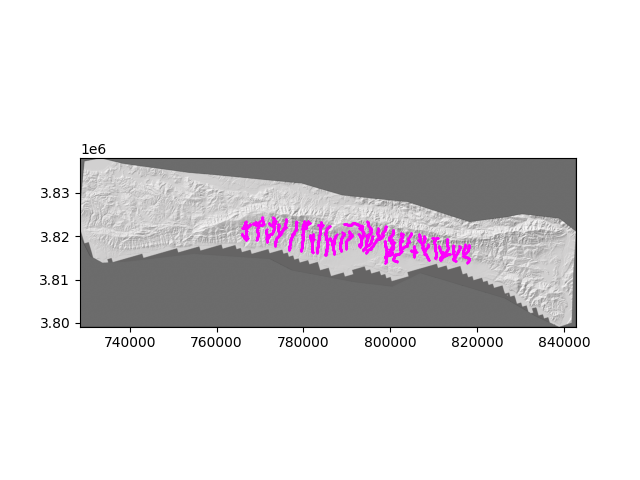

In [2]:
frd_model_file = Path("frdModels") / "sy_centralBasins.npz"

# Number of inversion knots in each direction.
# Use both x and y knots for a 2D inversion.
# Use only number_of_knots_in_x for a 1D inversion.
number_of_knots_in_x = 1
number_of_knots_in_y = 1

f_2d = chifrd.LoadFowardModel(
    str(frd_model_file),kx=number_of_knots_in_x,ky=number_of_knots_in_y)


f_1d= chifrd.LoadFowardModel(
    str(frd_model_file),kx=number_of_knots_in_x)

frdplt.PlotFowardMapWithRivers(f_2d) #plotting the forward model with the river network for verification

## Run the inversion

The next step is to run the inversion using the forward model.

At this stage, you can choose whether to invert the 2D model, `f_2d`, or the 1D model, `f_1d`.

The inversion setup can be repeated for different saved basin selections, different values of `kx` and `ky`.

In [3]:
inversion=chifrd.InvertLandScape(f_2d,std_m_n=0.05) 
# inverting the landscape using the 2D forward model
# here the assumption is that the apriori standard deviation of the m and n parameters is 0.05, 
# which is a relatively strong assumption. 
# You can see that larger values results in m/n values that likely not realistic 

Setting paramters for inversions
Loaded almost everything... keep your pants on!


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Almost there...let the inversion begin!
	 	 Computed Jacobiean in 1.0 seconds
	 	 Computed next point in 0.2 seconds
	 	 Computed soultion for next  point in 0.0 seconds
	 	 Computed uncretinaity for soultions in 0.1 seconds
	 i= 1 total misfit: 42.65%     step improvment:57.4%
	 	 Computed Jacobiean in 0.9 seconds
	 	 Computed next point in 0.1 seconds
	 	 Computed soultion for next  point in 0.0 seconds
	 	 Computed uncretinaity for soultions in 0.1 seconds
	 i= 2 total misfit: 38.76%     step improvment:3.9%
	 	 Computed Jacobiean in 0.9 seconds
	 	 Computed next point in 0.2 seconds
	 	 Computed soultion for next  point in 0.0 seconds
	 	 Computed uncretinaity for soultions in 0.1 seconds
	 i= 3 total misfit: 35.03%     step improvment:3.7%
	 	 Computed Jacobiean in 0.9 seconds
	 	 Computed next point in 0.2 seconds
	 	 Computed soultion for next  point in 0.0 seconds
	 	 Computed uncretinaity for soultions in 0.1 seconds
	 i= 4 total misfit: 27.28%     step improvment:7.8%
	 	 Com

## Plot the uplift solution

After running the inversion, the next step is to plot the inferred uplift solution using the forward model and the inversion parameters.

This plot shows the spatial pattern of rock uplift rate, $U(x,y)$, predicted by the inversion. In the figure below, we plot both the initial guess and the final solution to show how the inferred uplift field changes during the inversion.

The inversion results are stored in `inversion.step`, where each row corresponds to one inversion iteration:

```text
inversion.step[iteration_idx, 0]  -> m
inversion.step[iteration_idx, 1]  -> n
inversion.step[iteration_idx, 2]  -> slope
inversion.step[iteration_idx, 3:] -> uplift parameters
```

You can use these saved parameters to plot the uplift solution at different inversion steps using the loaded forward model, as demonstrated below.

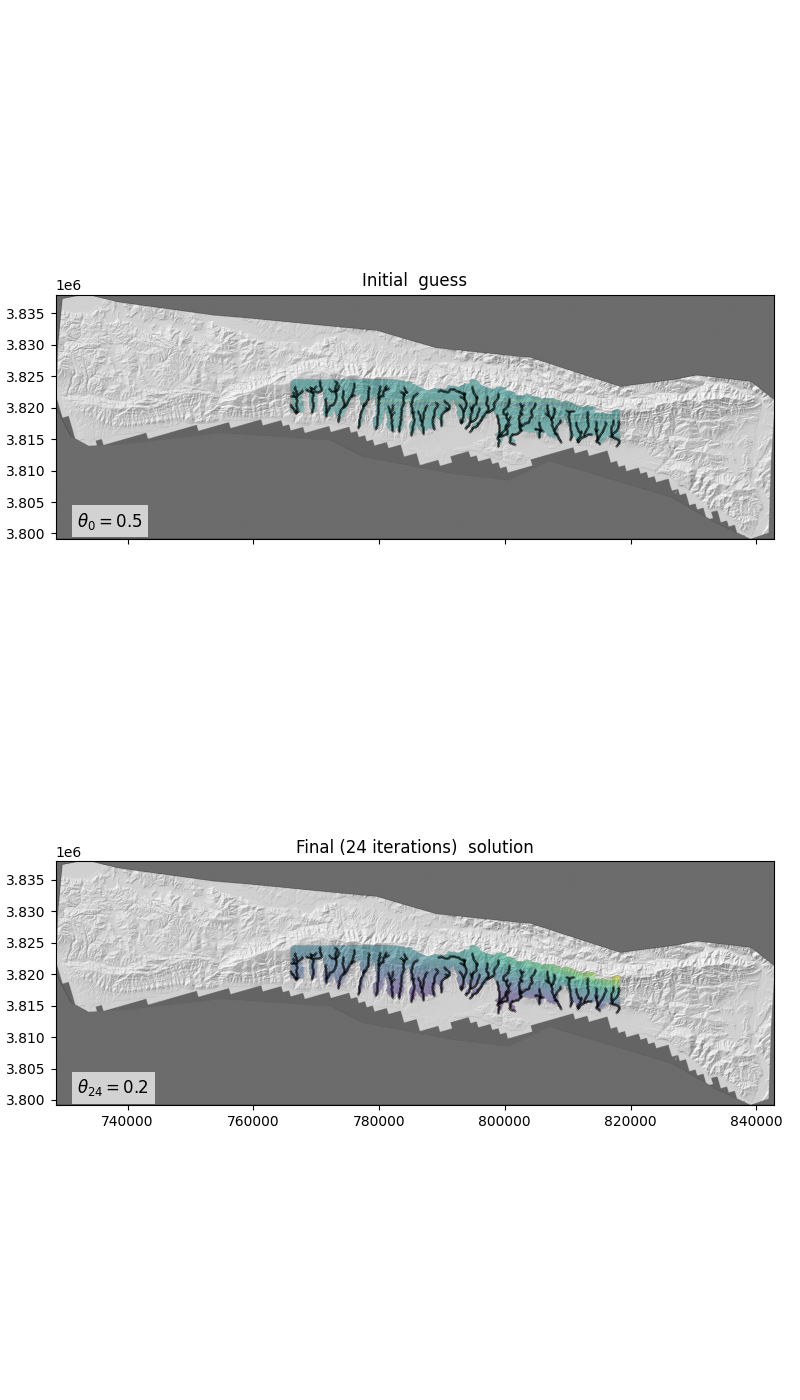

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=True, sharey=True)

n_steps = len(inversion.step[:, 0])

steps_to_plot = [0, n_steps]
labels = [r"\theta_0", rf"\theta_{{{n_steps}}}"]
titles = ["Initial  guess", f"Final ({n_steps} iterations)  solution"]

for ax, step_idx, theta_label, title in zip(axes, steps_to_plot, labels, titles):
    # 3: selects only the uplift parameters.
    # The first three parameters are m, n, and slope.
    uplift, cb = frdplt.Plot2DUpliftWithinBasins(
        f_2d.pixelMask,
        inversion.step[step_idx, 3:],
        f=f_2d,
        addColorBar=False,
        ax=ax,
        returnUplift=True,
    )

    m = inversion.step[step_idx, 0]
    n = inversion.step[step_idx, 1]
    theta = np.round(m / n, 2)

    ax.text(
        0.03, 0.03,
        rf"${theta_label} = {theta}$",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

    ax.set_title(title)

plt.tight_layout()